In [1]:
# Chunk 1: Load libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay)
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Load data
X_train = pd.read_csv("../Data/Splits/X_train_smote.csv")
y_train = pd.read_csv("../Data/Splits/y_train_smote.csv")['is_drop']
X_val = pd.read_csv("../Data/Splits/X_val.csv")
y_val = pd.read_csv("../Data/Splits/y_val.csv")['is_drop']
X_test = pd.read_csv("../Data/Splits/X_test.csv")
y_test = pd.read_csv("../Data/Splits/y_test.csv")['is_drop']

print("Data loaded successfully.")
print(f"Train (SMOTE): {X_train.shape}, drops: {y_train.sum()}")
print(f"Val: {X_val.shape}, drops: {y_val.sum()}")
print(f"Test: {X_test.shape}, drops: {y_test.sum()}")

Data loaded successfully.
Train (SMOTE): (2604, 27), drops: 1302
Val: (300, 27), drops: 21
Test: (300, 27), drops: 21


In [2]:
# Chunk 2: Evaluation function
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Print classification report, confusion matrix, ROC AUC and return predictions."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n{model_name} - Classification Report")
    print("="*40)
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Drop']))

    cm = confusion_matrix(y_test, y_pred)
    print(f"{model_name} - Confusion Matrix:\n", cm)

    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"\n{model_name} - ROC AUC: {roc_auc:.4f}")

    # Plot ROC curve
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{model_name} - ROC Curve")
    plt.grid(True)
    plt.show()

    return y_pred, y_proba


=== BASELINE XGBOOST ===

Baseline XGBoost - Classification Report
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98       279
        Drop       0.78      0.67      0.72        21

    accuracy                           0.96       300
   macro avg       0.88      0.83      0.85       300
weighted avg       0.96      0.96      0.96       300

Baseline XGBoost - Confusion Matrix:
 [[275   4]
 [  7  14]]

Baseline XGBoost - ROC AUC: 0.9659


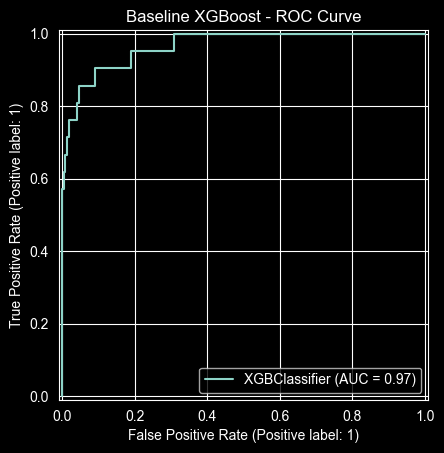


Baseline training gap (val_logloss - train_logloss): 0.0960


In [3]:
# Chunk 3: Baseline XGBoost with early stopping on validation set
RANDOM_STATE = 42

base_model = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    early_stopping_rounds=20,
    n_estimators=500
)

# Fit with validation set for early stopping
base_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Evaluate on test set
print("\n=== BASELINE XGBOOST ===")
y_pred_base, y_proba_base = evaluate_model(base_model, X_test, y_test, "Baseline XGBoost")

# Extract loss curves
base_results = base_model.evals_result()
train_logloss_base = base_results['validation_0']['logloss']
val_logloss_base = base_results['validation_1']['logloss']
epochs_base = range(1, len(train_logloss_base)+1)

# Training gap
gap_base = val_logloss_base[-1] - train_logloss_base[-1]
print(f"\nBaseline training gap (val_logloss - train_logloss): {gap_base:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best parameters from RandomizedSearchCV: {'colsample_bytree': np.float64(0.6036788206466518), 'gamma': np.float64(0.5073577143301605), 'learning_rate': np.float64(0.20905053073241675), 'max_depth': 7, 'n_estimators': 501, 'reg_alpha': np.float64(0.3216161028349973), 'reg_lambda': np.float64(1.0974675787331722), 'subsample': np.float64(0.8767580790770773)}

=== TUNED XGBOOST ===

Tuned XGBoost - Classification Report
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98       279
        Drop       0.70      0.67      0.68        21

    accuracy                           0.96       300
   macro avg       0.84      0.82      0.83       300
weighted avg       0.96      0.96      0.96       300

Tuned XGBoost - Confusion Matrix:
 [[273   6]
 [  7  14]]

Tuned XGBoost - ROC AUC: 0.9568


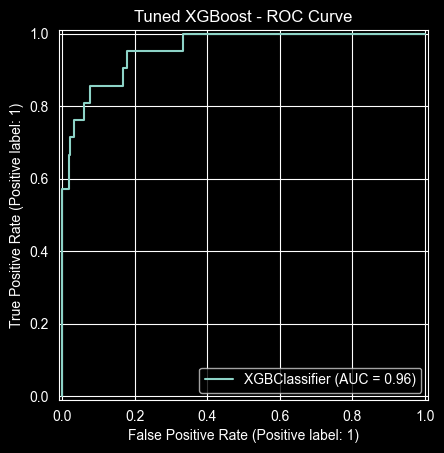


Tuned training gap (val_logloss - train_logloss): 0.0778


In [4]:
# Chunk 4 (corrected): Hyperparameter tuning + final model
param_dist = {
    'n_estimators': randint(100, 600),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0, 2),
}

xgb_temp = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
random_search = RandomizedSearchCV(
    xgb_temp, param_dist, n_iter=30, cv=3, scoring='roc_auc',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
random_search.fit(X_train, y_train)   # no early stopping inside CV

print("\nBest parameters from RandomizedSearchCV:", random_search.best_params_)
best_params = random_search.best_params_.copy()   # make a copy

# Add the fixed parameters (do NOT add n_estimators again)
best_params.update({
    'random_state': RANDOM_STATE,
    'eval_metric': 'logloss',
    'early_stopping_rounds': 20
})

# Final tuned model – uses the tuned n_estimators (no duplication)
tuned_model = xgb.XGBClassifier(**best_params)

tuned_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Evaluate tuned model
print("\n=== TUNED XGBOOST ===")
y_pred_tuned, y_proba_tuned = evaluate_model(tuned_model, X_test, y_test, "Tuned XGBoost")

# Loss curves
tuned_results = tuned_model.evals_result()
train_logloss_tuned = tuned_results['validation_0']['logloss']
val_logloss_tuned = tuned_results['validation_1']['logloss']
epochs_tuned = range(1, len(train_logloss_tuned)+1)
gap_tuned = val_logloss_tuned[-1] - train_logloss_tuned[-1]
print(f"\nTuned training gap (val_logloss - train_logloss): {gap_tuned:.4f}")

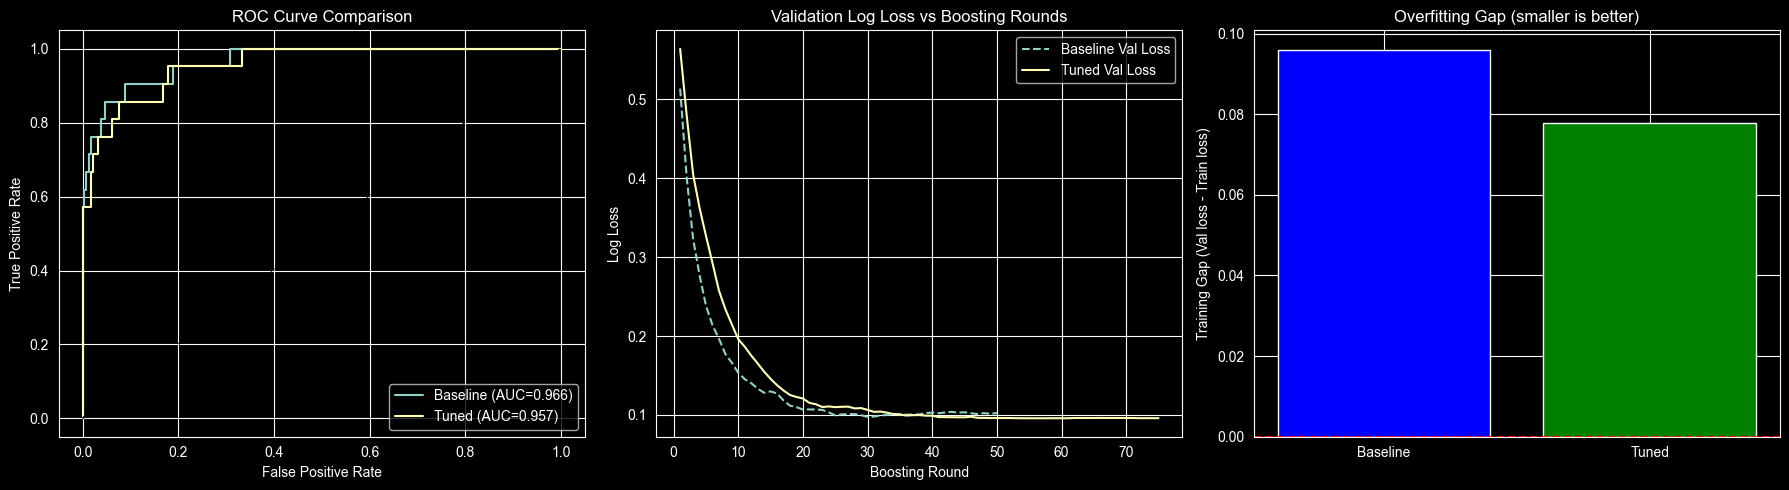

In [5]:
# Chunk 5: Comparison visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC curves comparison
from sklearn.metrics import roc_curve

# Baseline ROC
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
auc_base = roc_auc_score(y_test, y_proba_base)
# Tuned ROC
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_proba_tuned)
auc_tuned = roc_auc_score(y_test, y_proba_tuned)

axes[0].plot(fpr_base, tpr_base, label=f'Baseline (AUC={auc_base:.3f})')
axes[0].plot(fpr_tuned, tpr_tuned, label=f'Tuned (AUC={auc_tuned:.3f})')
axes[0].plot([0,1], [0,1], 'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend()

# 2. Loss curves (validation log loss over boosting rounds)
axes[1].plot(epochs_base, val_logloss_base, label='Baseline Val Loss', linestyle='--')
axes[1].plot(epochs_tuned, val_logloss_tuned, label='Tuned Val Loss', linestyle='-')
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('Log Loss')
axes[1].set_title('Validation Log Loss vs Boosting Rounds')
axes[1].legend()
axes[1].grid(True)

# 3. Training gap comparison (bar plot)
models = ['Baseline', 'Tuned']
gaps = [gap_base, gap_tuned]
axes[2].bar(models, gaps, color=['blue', 'green'])
axes[2].set_ylabel('Training Gap (Val loss - Train loss)')
axes[2].set_title('Overfitting Gap (smaller is better)')
axes[2].axhline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

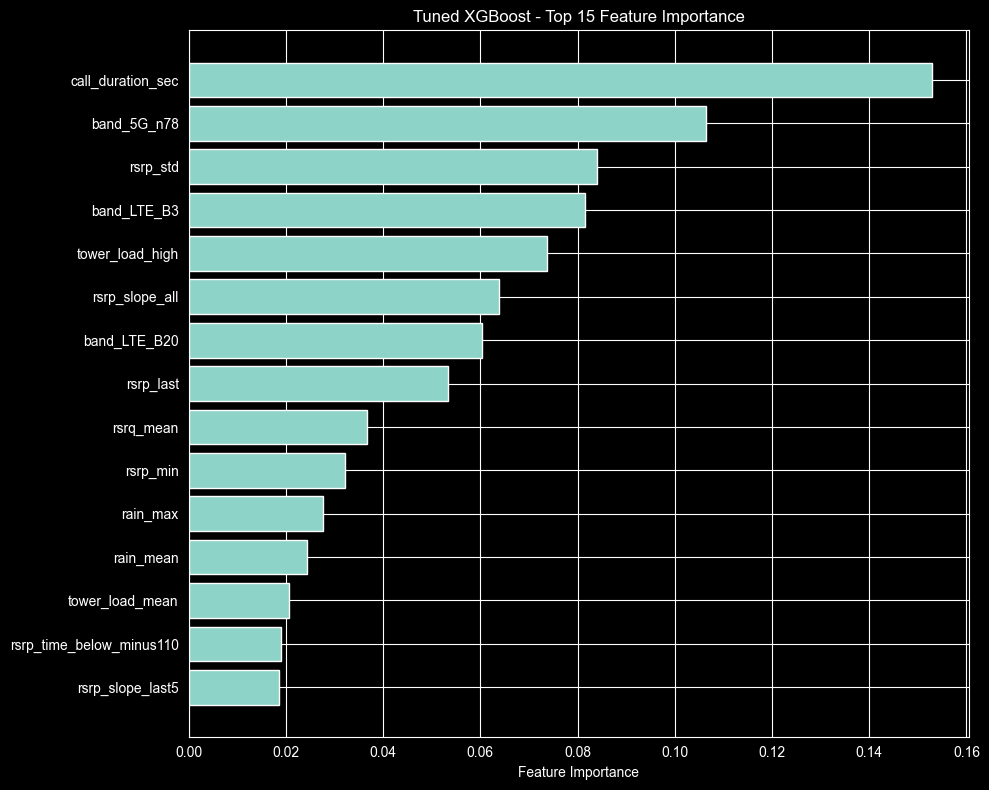


Top 10 most important features (Tuned XGBoost):
1. call_duration_sec: 0.1528
2. band_5G_n78: 0.1065
3. rsrp_std: 0.0840
4. band_LTE_B3: 0.0816
5. tower_load_high: 0.0736
6. rsrp_slope_all: 0.0638
7. band_LTE_B20: 0.0603
8. rsrp_last: 0.0533
9. rsrq_mean: 0.0366
10. rsrp_min: 0.0321


In [6]:
# Chunk 6: Feature importance for tuned model
importance = tuned_model.feature_importances_
feat_names = X_train.columns
sorted_idx = np.argsort(importance)[::-1]

plt.figure(figsize=(10, 8))
plt.barh(range(15), importance[sorted_idx[:15]][::-1])
plt.yticks(range(15), [feat_names[i] for i in sorted_idx[:15]][::-1])
plt.xlabel('Feature Importance')
plt.title('Tuned XGBoost - Top 15 Feature Importance')
plt.tight_layout()
plt.show()

# Print top 10
print("\nTop 10 most important features (Tuned XGBoost):")
for i in range(10):
    print(f"{i+1}. {feat_names[sorted_idx[i]]}: {importance[sorted_idx[i]]:.4f}")

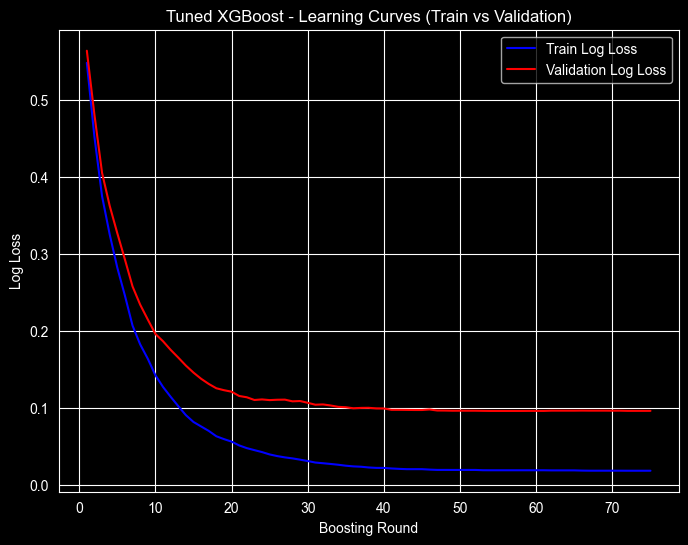

In [7]:
# Chunk 7: Learning curves (train vs validation loss for tuned model)
plt.figure(figsize=(8, 6))
plt.plot(epochs_tuned, train_logloss_tuned, 'b-', label='Train Log Loss')
plt.plot(epochs_tuned, val_logloss_tuned, 'r-', label='Validation Log Loss')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('Tuned XGBoost - Learning Curves (Train vs Validation)')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Chunk 8: Model comparison with ranking based on recall, gap, precision
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

def get_metrics(y_true, y_pred, y_proba):
    """Return a dictionary of metrics."""
    return {
        'Accuracy': (y_true == y_pred).mean(),
        'Precision (Drop)': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall (Drop)': recall_score(y_true, y_pred, pos_label=1),
        'F1 (Drop)': f1_score(y_true, y_pred, pos_label=1),
        'ROC AUC': roc_auc_score(y_true, y_proba)
    }

# Compute metrics for both models
metrics_base = get_metrics(y_test, y_pred_base, y_proba_base)
metrics_tuned = get_metrics(y_test, y_pred_tuned, y_proba_tuned)

# Add training gap (already computed from earlier chunks)
metrics_base['Training Gap'] = gap_base
metrics_tuned['Training Gap'] = gap_tuned

# Create DataFrame
comparison = pd.DataFrame([metrics_base, metrics_tuned], index=['Baseline', 'Tuned'])
print("\n=== FULL MODEL COMPARISON ===")
print(comparison.round(4))

# ==============================
# Ranking Logic (choose best model)
# ==============================
# Priority: 1) Recall (Drop) – catch drops, 2) Training Gap (smaller better),
#           3) Precision (Drop) – avoid false alarms
# We'll compute a simple weighted score: higher is better
# Score = Recall*0.5 + (1 - Gap)*0.3 + Precision*0.2
# (Gap normalized: assume max gap 0.2 is worst, so (0.2 - gap)/0.2 gives a 0-1 score)

def rank_model(row):
    recall = row['Recall (Drop)']
    precision = row['Precision (Drop)']
    gap = row['Training Gap']
    # Normalize gap: 0 gap = 1.0, gap >= 0.2 = 0.0
    gap_score = max(0, (0.2 - min(gap, 0.2)) / 0.2)
    score = recall * 0.5 + gap_score * 0.3 + precision * 0.2
    return score

comparison['Score'] = comparison.apply(rank_model, axis=1)
comparison = comparison.sort_values('Score', ascending=False)

print("\n=== MODEL RANKING (1st = best) ===")
for i, (model_name, row) in enumerate(comparison.iterrows(), 1):
    print(f"{i}st: {model_name} (Score = {row['Score']:.3f})")
    print(f"    Recall = {row['Recall (Drop)']:.3f}, Precision = {row['Precision (Drop)']:.3f}, Gap = {row['Training Gap']:.4f}")

# Explicitly state the best model
best_model_name = comparison.index[0]
print(f"\n🏆 Recommended Model: {best_model_name}")


=== FULL MODEL COMPARISON ===
          Accuracy  Precision (Drop)  Recall (Drop)  F1 (Drop)  ROC AUC  \
Baseline    0.9633            0.7778         0.6667     0.7179   0.9659   
Tuned       0.9567            0.7000         0.6667     0.6829   0.9568   

          Training Gap  
Baseline        0.0960  
Tuned           0.0778  

=== MODEL RANKING (1st = best) ===
1st: Tuned (Score = 0.657)
    Recall = 0.667, Precision = 0.700, Gap = 0.0778
2st: Baseline (Score = 0.645)
    Recall = 0.667, Precision = 0.778, Gap = 0.0960

🏆 Recommended Model: Tuned


In [9]:
# Chunk 9: Save models to disk
import os
import joblib

# Create directory if it doesn't exist
os.makedirs("../Models", exist_ok=True)

# Save baseline model
joblib.dump(base_model, "../Models/baseline_xgb.pkl")
print("Baseline model saved to ../Models/baseline_xgb.pkl")

# Save tuned model
joblib.dump(tuned_model, "../Models/tuned_xgb.pkl")
print("Tuned model saved to ../Models/tuned_xgb.pkl")



Baseline model saved to ../Models/baseline_xgb.pkl
Tuned model saved to ../Models/tuned_xgb.pkl
